In [1]:
import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from cuda.CRU import CRUs, RyR_stationary, LCC_stationary
from params import RestrepoParams
#from currents import get_ICa

In [196]:
ci = 0.1 * np.ones((200, 200), dtype=np.float32)
cs = 0.1 * np.ones((200, 200), dtype=np.float32)
cp = 0.1 * np.ones((200, 200), dtype=np.float32)

cjsr = 750.0 * np.ones((200,200), dtype=np.float32)
cnsr = 750.0 * np.ones((200,200), dtype=np.float32)

CaTi = 20.0 * np.ones((200,200), dtype=np.float32)
CaTs = 20.0 * np.ones((200,200), dtype=np.float32)

params = RestrepoParams(Ku=1.4e-4, h=2.5)

In [197]:
RyR = RyR_stationary(cp, params)

In [198]:
LCC = LCC_stationary(cp, 0.1, params)

In [199]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs)

In [373]:
cru_obj.forward(15.0, 78.0, 1e-3, nstep=10000, _tpb2d=32, _tpb1d=256)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


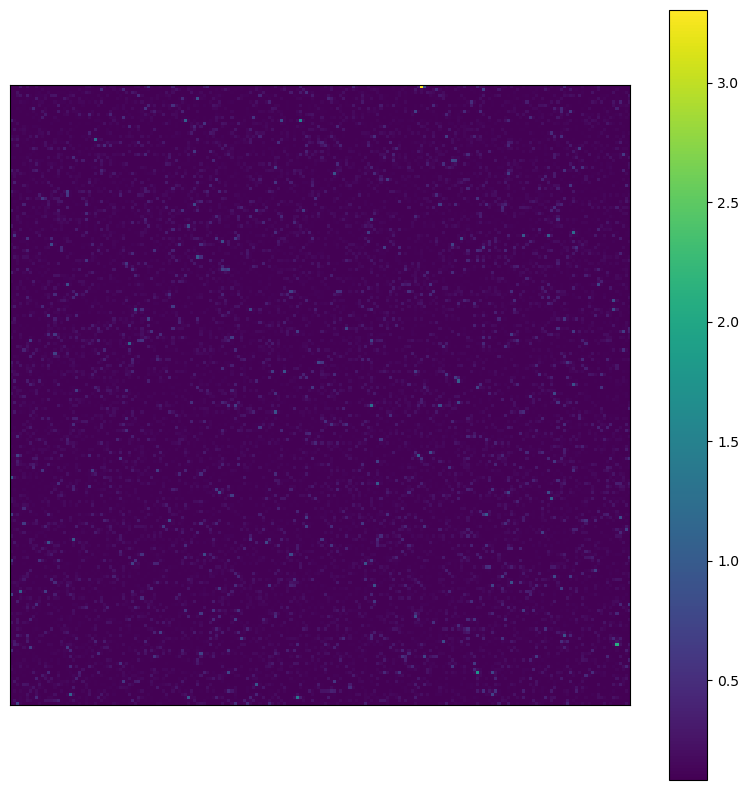

In [374]:
fig, ax = plt.subplots(1, figsize=(10,10))
im = ax.imshow(cru_obj.cs, aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
fig.colorbar(im)
plt.show()

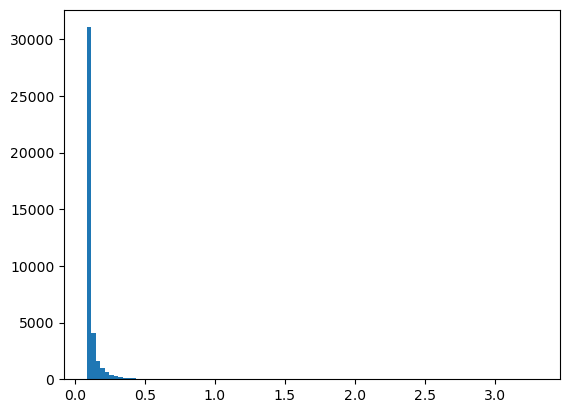

In [378]:
plt.hist(cru_obj.cs.reshape(-1), bins=100)
plt.show()

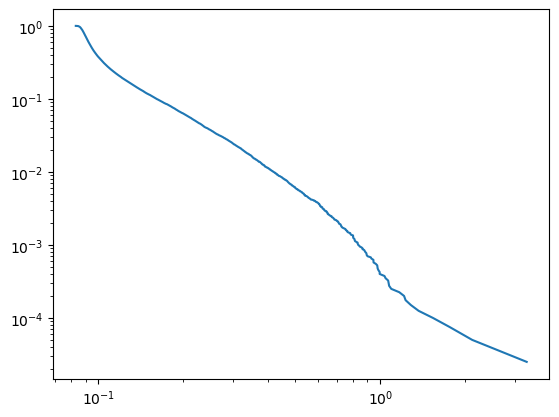

In [379]:
def ccdf(arr):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

ps, bins = ccdf(cru_obj.cs.reshape(-1))
plt.plot(bins, ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [380]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [381]:
modes = ifftshift(fft2(fftshift((cru_obj.cs - cru_obj.cs.mean())), norm="ortho"))

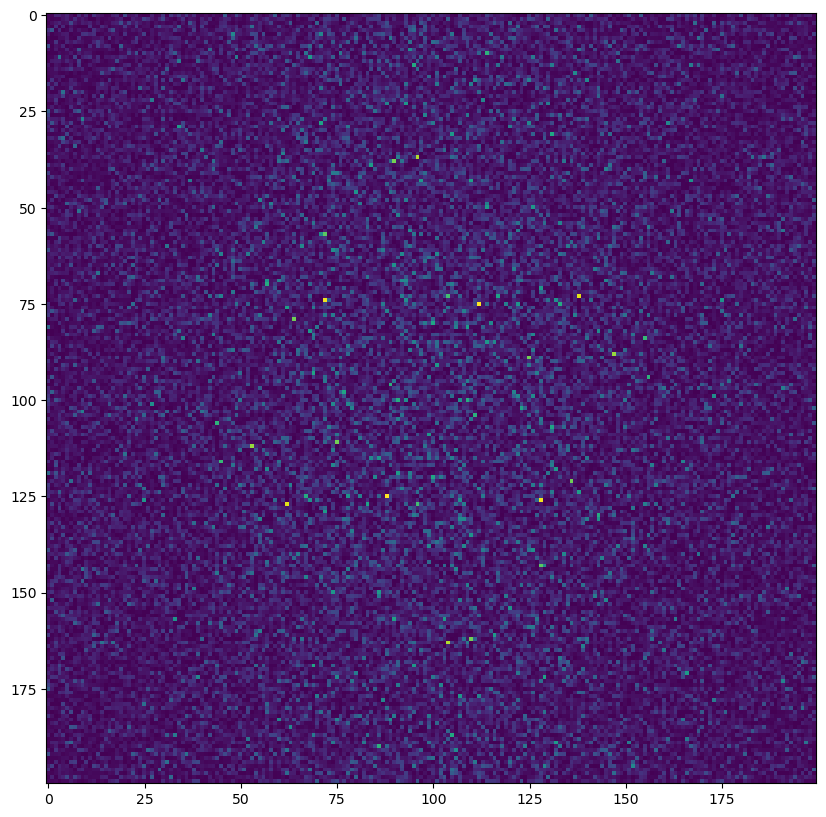

In [382]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

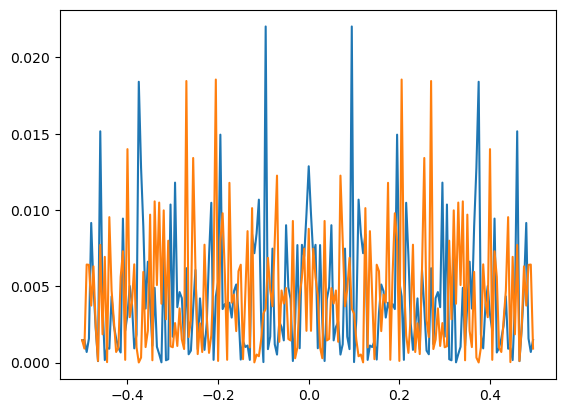

In [383]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [384]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

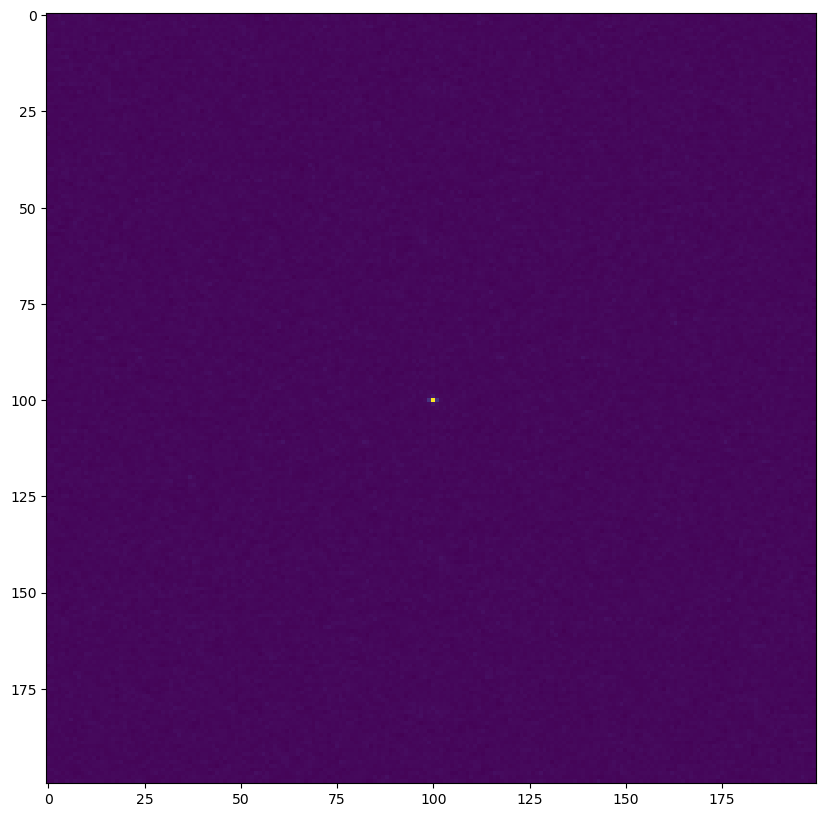

In [385]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

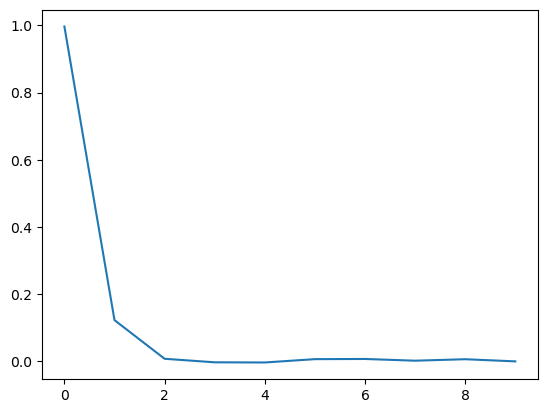

In [386]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()